# The Impact of Green Economy Practices on Firm Innovation: Evidence from Indonesian Manufacturing and Service Sectors
**Data:** Indonesian Manufacturing and Service Sectors Enterprise Survey 2023 — World Bank

---
## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from stargazer.stargazer import Stargazer

---
## 1. Load Data

In [2]:
df = pd.read_stata('Indonesia-2023-full-data.dta')

# Filter exclusively for Version B (Green Economy Transition module)
df_b = df[df['q_version'] == 'B - Green Economy and Taxes Module'].copy()
print(f"Initial Version B sample size: {len(df_b)} firms")

Initial Version B sample size: 1512 firms


---
## 2. DATA CLEANING & FEATURE ENGINEERING

### 2.1 Dependent Variable
- We use np.select to map Yes(1) to 1, No(2) to 0.
- default=np.nan ensures that "Don't Know" (-9) and "Refuse" (-8) become missing values!

In [3]:
cond_prod = [df_b['h1'] == 1, df_b['h1'] == 2]
cond_proc = [df_b['h5'] == 1, df_b['h5'] == 2]

# Safely check if Stata loaded them as categories ('Yes'/'No') instead of numbers
if df_b['h1'].dtype.name == 'category':
    cond_prod = [df_b['h1'] == 'Yes', df_b['h1'] == 'No']
    cond_proc = [df_b['h5'] == 'Yes', df_b['h5'] == 'No']

df_b['PRODUCT'] = np.select(cond_prod, [1, 0], default=np.nan)
df_b['PROCESS'] = np.select(cond_proc, [1, 0], default=np.nan)


### 2.2 Independent Variable (GEP Index)

Sum across the 10 columns. min_count=1 ensures that if all 10 are NaN, the index is NaN (not 0)

In [4]:
gep_cols = [f'ge8{chr(97+i)}_BR' for i in range(10)]
bin_cols = []

for col in gep_cols:
    cond_gep = [df_b[col] == 1, df_b[col] == 2]
    if df_b[col].dtype.name == 'category':
        cond_gep = [df_b[col] == 'Yes', df_b[col] == 'No']

    bin_col_name = f'{col}_bin'
    df_b[bin_col_name] = np.select(cond_gep, [1, 0], default=np.nan)
    bin_cols.append(bin_col_name)


df_b['GEP_Index'] = df_b[bin_cols].sum(axis=1, min_count=1)


### 2.2 Control Variables

In [5]:
# 1. Firm Size (Log of full-time employees, l1)
df_b['SIZE'] = np.log(pd.to_numeric(df_b['l1'], errors='coerce').replace(0, np.nan))

# 2. Firm Age (Log of years since operations began, 2023 - b5)
df_b['AGE'] = np.log(2023 - pd.to_numeric(df_b['b5'], errors='coerce').replace(0, np.nan))

# 3. Cash Flow (k6: Checking/savings account)
cond_k6 = [df_b['k6'] == 1, df_b['k6'] == 2]
if df_b['k6'].dtype.name == 'category': cond_k6 = [df_b['k6'] == 'Yes', df_b['k6'] == 'No']
df_b['CFL'] = np.select(cond_k6, [1, 0], default=np.nan)

# 4. Debt (k82: Line of credit/loan)
cond_k82 = [df_b['k82'] == 1, df_b['k82'] == 2]
if df_b['k82'].dtype.name == 'category': cond_k82 = [df_b['k82'] == 'Yes', df_b['k82'] == 'No']
df_b['DEBT'] = np.select(cond_k82, [1, 0], default=np.nan)

# 5. Foreign Ownership (b2b: Percentage owned by foreigners)
df_b['FO'] = pd.to_numeric(df_b['b2b'], errors='coerce')
df_b['FO'] = np.where(df_b['FO'] < 0, np.nan, df_b['FO']) # Remove -9 or -8 responses

# --- D. Interaction Term & Fixed Effects ---
df_b['GEP_x_SIZE'] = df_b['GEP_Index'] * df_b['SIZE']
sector_dummies = pd.get_dummies(df_b['a0'], drop_first=True, dtype=int)
df_b = pd.concat([df_b, sector_dummies], axis=1)

---
## 3. EXPLORATORY DATA ANALYSIS (EDA)

### 3.1 Histogram of the GEP Index

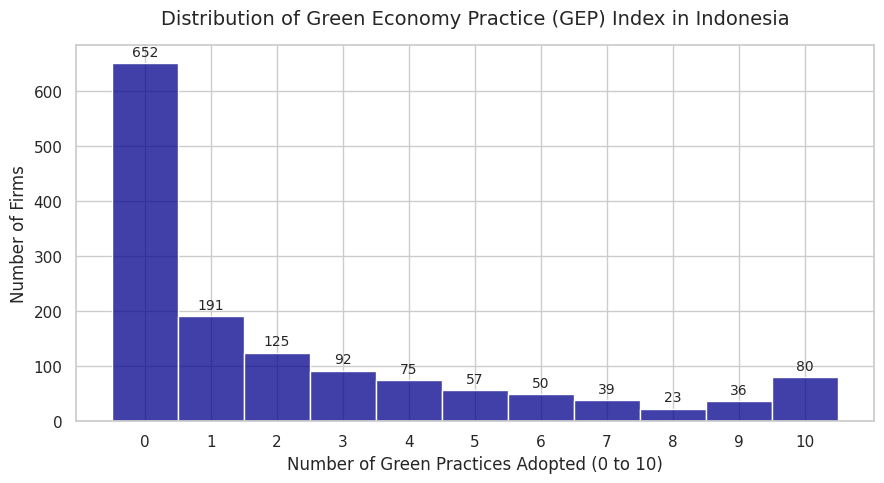

In [6]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))
ax1 = sns.histplot(df_b['GEP_Index'].dropna(), bins=range(0, 12), discrete=True, color='darkblue')
plt.title('Distribution of Green Economy Practice (GEP) Index in Indonesia', fontsize=14, pad=15)
plt.xlabel('Number of Green Practices Adopted (0 to 10)', fontsize=12)
plt.ylabel('Number of Firms', fontsize=12)
plt.xticks(range(0, 11))

# Add data labels on top of the bars
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig('EDA_1_GEP_Histogram.png', dpi=300)
plt.show()

### 3.2 Bar Chart of Specific Green Practices

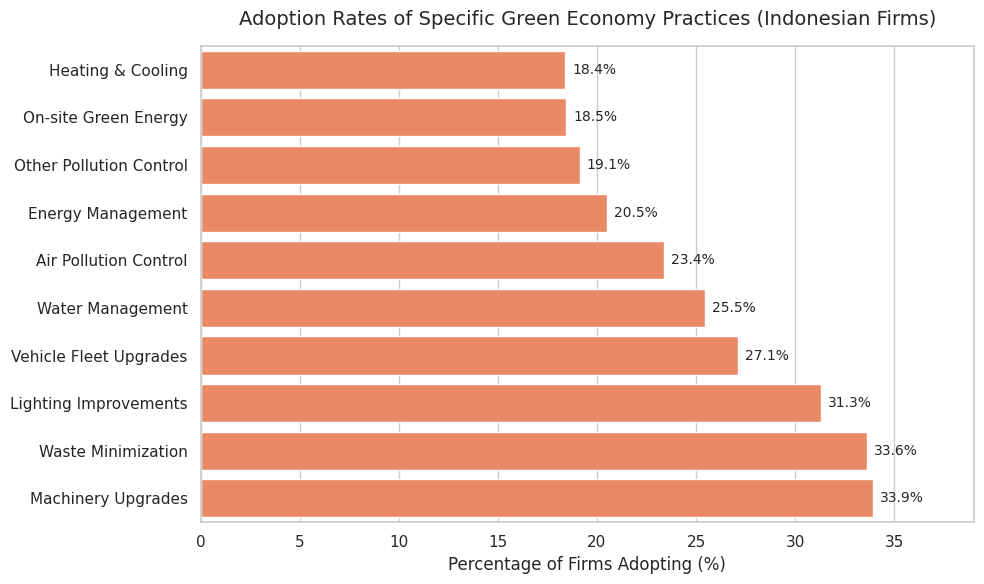

In [7]:
adoption_rates = df_b[bin_cols].mean() * 100
practice_names = [
    'Heating & Cooling', 'On-site Green Energy', 'Machinery Upgrades',
    'Energy Management', 'Waste Minimization', 'Air Pollution Control',
    'Water Management', 'Vehicle Fleet Upgrades', 'Lighting Improvements',
    'Other Pollution Control'
]
plot_df = pd.DataFrame({'Practice': practice_names, 'Adoption Rate (%)': adoption_rates.values})
plot_df = plot_df.sort_values('Adoption Rate (%)', ascending=True)

plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Adoption Rate (%)', y='Practice', data=plot_df, color='coral')
plt.title('Adoption Rates of Specific Green Economy Practices (Indonesian Firms)', fontsize=14, pad=15)
plt.xlabel('Percentage of Firms Adopting (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, max(plot_df['Adoption Rate (%)']) * 1.15)

# Add data labels next to the bars
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=10, xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.savefig('EDA_2_GEP_BarChart.png', dpi=300)
plt.show()

---
## 4. PREPARE DATA FOR MODELING

### 4.1 Keep All The Variables that We Used

In [8]:
cols_to_keep = ['PRODUCT', 'PROCESS', 'GEP_Index', 'SIZE', 'GEP_x_SIZE',
                'AGE', 'CFL', 'DEBT', 'FO', 'wmedian_BR'] + list(sector_dummies.columns)

# Drop rows with ANY missing data in these critical columns
df_clean = df_b[cols_to_keep].dropna().copy()
print(f"Final sample size after dropping missing values (NaNs): {len(df_clean)} firms")

# Setup Independent Variables (X)
X_cols = ['GEP_Index', 'SIZE', 'GEP_x_SIZE', 'AGE', 'CFL', 'DEBT', 'FO'] + list(sector_dummies.columns)
X = df_clean[X_cols]
X = sm.add_constant(X)

Final sample size after dropping missing values (NaNs): 794 firms


### 4.2 Check for Zero Variance

In [9]:
# Check for zero variance, but EXPLICITLY PROTECT the 'const' (intercept)
empty_columns = [col for col in X.columns if X[col].var() == 0 and col != 'const']

if len(empty_columns) > 0:
    print(f"Dropping zero-variance variables: {empty_columns}")
    X = X.drop(columns=empty_columns)

Dropping zero-variance variables: ['DEBT']


---
## 5. ECONOMETRIC MODELING (GLM with Sampling Weights)

### 5.1 Model 1: Product Innovation

In [10]:
model_prod_logit = sm.GLM(
    df_clean['PRODUCT'],
    X,
    family=sm.families.Binomial(),
    var_weights=df_clean['wmedian_BR']
).fit(cov_type='hc1')

print(model_prod_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                PRODUCT   No. Observations:                  794
Model:                            GLM   Df Residuals:                      785
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -17144.
Date:                Wed, 27 May 2026   Deviance:                       34289.
Time:                        16:02:33   Pearson chi2:                 1.21e+05
No. Iterations:                     8   Pseudo R-squ. (CS):             0.9942
Covariance Type:                  hc1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.7749      2.430     

### 5.2 Model 2: Process Innovation

In [11]:
model_proc_logit = sm.GLM(
    df_clean['PROCESS'],
    X,
    family=sm.families.Binomial(),
    var_weights=df_clean['wmedian_BR']
).fit(cov_type='hc1')

print(model_proc_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                PROCESS   No. Observations:                  794
Model:                            GLM   Df Residuals:                      785
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7565.1
Date:                Wed, 27 May 2026   Deviance:                       15130.
Time:                        16:02:33   Pearson chi2:                 4.97e+05
No. Iterations:                     9   Pseudo R-squ. (CS):             0.9998
Covariance Type:                  hc1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -13.8915      3.227     

---
## 6. EXPORT RESULTS FOR RESEARCH PAPER

In [12]:
stargazer = Stargazer([model_prod_logit, model_proc_logit])
stargazer.title("Impact of Green Economy Practices on Firm Innovation in Indonesia (Weighted)")
stargazer.custom_columns(["Product Innovation", "Process Innovation"], [1, 1])
stargazer.show_model_numbers(True)
stargazer.significant_digits(3)

print("\n--- BASELINE ECONOMETRIC RESULTS ---")
print(stargazer)

# Export to an HTML file
with open("Econometric_Results.html", "w") as f:
    f.write(stargazer.render_html())

print("\nProcess Complete! Table saved as 'Econometric_Results.html'")


--- BASELINE ECONOMETRIC RESULTS ---

Process Complete! Table saved as 'Econometric_Results.html'


---
## 7. ROBUSTNESS CHECKS (PROBIT MODEL)

## 7.1 Model 1: Product Innovation

In [13]:
model_prod_probit = sm.GLM(
    df_clean['PRODUCT'],
    X,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_clean['wmedian_BR']
).fit(cov_type='hc1')

print(model_prod_probit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                PRODUCT   No. Observations:                  794
Model:                            GLM   Df Residuals:                      785
Model Family:                Binomial   Df Model:                            8
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -17044.
Date:                Wed, 27 May 2026   Deviance:                       34088.
Time:                        16:02:34   Pearson chi2:                 1.18e+05
No. Iterations:                    10   Pseudo R-squ. (CS):             0.9955
Covariance Type:                  hc1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -1.5182      0.967     

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(


## 7.2 Model 2: Process Innovation

In [14]:
model_proc_probit = sm.GLM(
    df_clean['PROCESS'],
    X,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_clean['wmedian_BR']
).fit(cov_type='hc1')

print(model_proc_probit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The probit link alias is deprecated. Use Probit instead. The probit link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                PROCESS   No. Observations:                  794
Model:                            GLM   Df Residuals:                      785
Model Family:                Binomial   Df Model:                            8
Link Function:                 probit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7568.6
Date:                Wed, 27 May 2026   Deviance:                       15137.
Time:                        16:02:34   Pearson chi2:                 6.37e+05
No. Iterations:                    12   Pseudo R-squ. (CS):             0.9998
Covariance Type:                  hc1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.2134      1.347     

---
## 7. EXPORT ROBUSTNESS CHECK

In [15]:
stargazer_rob = Stargazer([model_prod_probit, model_proc_probit])
stargazer_rob.title("Robustness Check: Probit Model Estimations")
stargazer_rob.custom_columns(["Product (Probit)", "Process (Probit)"], [1, 1])
stargazer_rob.show_model_numbers(True)
stargazer_rob.significant_digits(3)

print("\n--- ROBUSTNESS ECONOMETRIC RESULTS ---")
print(stargazer)

with open("Robustness_Results.html", "w") as f:
    f.write(stargazer_rob.render_html())


--- ROBUSTNESS ECONOMETRIC RESULTS ---


---
## 8. MARGINAL EFFECTS

### 8.1 Model 1: PRODUCT INNOVATION

In [16]:
print("=== PRODUCT INNOVATION ===")
odds_ratios_prod = np.exp(model_prod_logit.params)
print(f"Odds Ratio for GEP_Index: {odds_ratios_prod['GEP_Index']:.3f}")

pred_probs_prod = model_prod_logit.predict()
pdf_values_prod = pred_probs_prod * (1 - pred_probs_prod)
ind_margeff_prod = model_prod_logit.params['GEP_Index'] * pdf_values_prod
ame_gep_prod = np.average(ind_margeff_prod, weights=df_clean['wmedian_BR'])
print(f"Average Marginal Effect for GEP_Index: {ame_gep_prod:.4f} ({ame_gep_prod * 100:.2f}%)\n")

=== PRODUCT INNOVATION ===
Odds Ratio for GEP_Index: 1.590
Average Marginal Effect for GEP_Index: 0.0135 (1.35%)



### 8.2 Model 2: PROCESS INNOVATION

In [17]:
print("=== PROCESS INNOVATION ===")
odds_ratios_proc = np.exp(model_proc_logit.params)
print(f"Odds Ratio for GEP_Index: {odds_ratios_proc['GEP_Index']:.3f}")

pred_probs_proc = model_proc_logit.predict()
pdf_values_proc = pred_probs_proc * (1 - pred_probs_proc)
ind_margeff_proc = model_proc_logit.params['GEP_Index'] * pdf_values_proc
ame_gep_proc = np.average(ind_margeff_proc, weights=df_clean['wmedian_BR'])
print(f"Average Marginal Effect for GEP_Index: {ame_gep_proc:.4f} ({ame_gep_proc * 100:.2f}%)")

print("\nProcess Complete! All files generated successfully.")

=== PROCESS INNOVATION ===
Odds Ratio for GEP_Index: 3.103
Average Marginal Effect for GEP_Index: 0.0140 (1.40%)

Process Complete! All files generated successfully.


# COMPLETED

## ADDITIONAL (DESCRIPTIVE STATISTICS)

In [18]:
# 1. Create the RAW variables in df_clean first
df_clean['RAW_WORKERS'] = pd.to_numeric(df_b['l1'], errors='coerce')
df_clean['RAW_AGE'] = 2023 - pd.to_numeric(df_b['b5'], errors='coerce')

# 2. Define the exact variables you want in the table (using RAW versions)
vars_to_describe = ['PRODUCT', 'PROCESS', 'GEP_Index', 'CFL', 'RAW_WORKERS', 'FO', 'RAW_AGE']

# 3. Use Pandas built-in .describe() function and transpose it (.T)
summary_stats = df_clean[vars_to_describe].describe().T

# 4. Select only the columns we need to match the Phan paper
summary_stats = summary_stats[['count', 'mean', 'std', 'min', 'max']]

# 5. Rename the columns exactly as they appear in the image
summary_stats.columns = ['Observations', 'Mean', 'Standard Deviation', 'Minimum', 'Maximum']

# 6. Format the numbers for a clean look
# Convert Observations to integers (no decimals)
summary_stats['Observations'] = summary_stats['Observations'].astype(int)

# Format the rest of the columns to 4 decimal places to match the Phan paper's precision
for col in ['Mean', 'Standard Deviation', 'Minimum', 'Maximum']:
    summary_stats[col] = summary_stats[col].apply(lambda x: f"{x:.4f}")

# Print cleanly to the console
print("\n--- SUMMARY STATISTICS ---")
print(summary_stats.to_string())

# 7. Export to HTML for easy copy-pasting into MS Word
# We move the index to a proper column named 'Variables' for the export
summary_stats_reset = summary_stats.reset_index().rename(columns={'index': 'Variables'})

html_table = summary_stats_reset.to_html(index=False, justify='center', border=1)
html_output = f"""
    <h3 style="text-align:center;">Table 1: Summary Statistics</h3>
    {html_table}
"""

with open("Summary_Statistics_Phan_Format.html", "w") as f:
    f.write(html_output)

print("\nProcess Complete! Table saved as 'Summary_Statistics_Phan_Format.html'")


--- SUMMARY STATISTICS ---
             Observations     Mean Standard Deviation Minimum    Maximum
PRODUCT               794   0.0466             0.2109  0.0000     1.0000
PROCESS               794   0.0214             0.1448  0.0000     1.0000
GEP_Index             794   2.1776             3.1635  0.0000    10.0000
CFL                   794   0.7456             0.4358  0.0000     1.0000
RAW_WORKERS           794  52.7695           141.0357  1.0000  2000.0000
FO                    794   2.1134            12.6275  0.0000   100.0000
RAW_AGE               794  19.0189            12.6908  1.0000   113.0000

Process Complete! Table saved as 'Summary_Statistics_Phan_Format.html'


In [19]:
# 1. Create the RAW variables in df_clean first (if you haven't already)
df_clean['RAW_WORKERS'] = pd.to_numeric(df_b['l1'], errors='coerce')
df_clean['RAW_AGE'] = 2023 - pd.to_numeric(df_b['b5'], errors='coerce')

# 2. Swap out SIZE and AGE for RAW_WORKERS and RAW_AGE in your list!
vars_to_describe = ['PRODUCT', 'PROCESS', 'GEP_Index', 'CFL', 'DEBT', 'RAW_WORKERS', 'FO', 'RAW_AGE']

# 3. Run the describe function exactly as you did before
summary_stats = df_clean[vars_to_describe].describe()